In [1]:
%load_ext autoreload
%autoreload 2

# `import`

In [ ]:
import numpy as np

import gymnasium as gym

from gymnasium.wrappers.time_limit import TimeLimit

from dice_rl_TU_Vienna.environment import test_env
from dice_rl_TU_Vienna.wrappers import LoopingWrapper
from dice_rl_TU_Vienna.dataset import get_dataset
from dice_rl_TU_Vienna.value import get_get_policy_value, get_success_rate
from dice_rl_TU_Vienna.latex import latex_labels
from dice_rl_TU_Vienna.plot.tabular import plot
from dice_rl_TU_Vienna.plugins.stable_baselines3.policy import get_model_PPO
from dice_rl_TU_Vienna.plugins.stable_baselines3.dataset import get_probs

from dice_rl_TU_Vienna.estimators.get import (
    get_pv_s_OnPE, get_pv_s_OffPE, get_sdc_s, get_vaf_s, )
from dice_rl_TU_Vienna.estimators.tabular.test import test_auxiliary_estimates
from dice_rl_TU_Vienna.estimators.tabular.tabular_vafe          import TabularVafe
from dice_rl_TU_Vienna.estimators.tabular.tabular_dice          import TabularDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_dual_dice     import TabularDualDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_gradient_dice import TabularGradientDice
from dice_rl_TU_Vienna.estimators.tabular.tabular_OffPE         import AuxiliaryEstimates

from dice_rl_TU_Vienna.utils.general import iterate_print
from dice_rl_TU_Vienna.utils.bedtime import computer_sleep

from plugins.gymnasium.frozen_lake.config import *
from plugins.gymnasium.frozen_lake.analytical_solver import AnalyticalSolverFrozenLake
from plugins.gymnasium.frozen_lake.transition_lister import (
    get_transitions_sample, get_transitions_exact,
    list_transitions_sample, list_transitions_exact, )

# Prepare

In [3]:
env = {
    kind: gym.make(
        "FrozenLake-v1", desc=None, map_name="4x4", is_slippery=is_slippery[kind],
    )
        for kind in kinds
}

env_looping = { k: LoopingWrapper(v) for k, v in env.items() }

env_looping_time_limit = {
    k: TimeLimit(env=v, max_episode_steps=max_episode_steps)
        for k, v in env_looping.items()
}

In [4]:
policy     = {}
id_policy  = {}
dir_policy = {}

for kind in kinds:
    x, y = get_model_PPO(
        dir_env[kind],
        env[kind],
        {
            "seed": seed,
            "total_timesteps": total_timesteps,
        },
        verbosity=1,
    )

    policy[kind] = x
    id_policy[kind] = y
    dir_policy[kind] = os.path.join(dir_env[kind], id_policy[kind])

get_act_deterministic_uniform = lambda obs: env["deterministic"].action_space.sample()
get_act_stochastic_uniform    = lambda obs: env["stochastic"]   .action_space.sample()

get_act_deterministic_policy = lambda obs: int( policy["deterministic"].predict(obs)[0] )
get_act_stochastic_policy    = lambda obs: int( policy["stochastic"]   .predict(obs)[0] )

get_act = {
    "deterministic": {
        "uniform": get_act_deterministic_uniform,
        "policy":  get_act_deterministic_policy,
    },
    "stochastic": {
        "uniform": get_act_stochastic_uniform,
        "policy":  get_act_stochastic_policy,
    },
}

trying to find id_policy in data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/policy.json
trying to load policy from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T12:49:12.104856/policy.zip
trying to find id_policy in data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/policy.json
trying to load policy from data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T12:50:48.513450/policy.zip


In [5]:
dataset     = { kind: { by: {} for by in bys } for kind in kinds }
id_dataset  = { kind: { by: {} for by in bys } for kind in kinds }
dir_dataset = { kind: { by: {} for by in bys } for kind in kinds }

for kind in kinds:
    up = "uniform"

    x, y = get_dataset(
        dir_env[kind],
        env_looping[kind],
        get_act[kind][up],
        {
            "seed": seed,
            "n_samples": n_samples,
            "policy": None,
        },
        verbosity=1,
    )
    x["probs_init"] = list( get_probs(x["obs_init"], policy[kind], n_act) )
    x["probs_next"] = list( get_probs(x["obs_next"], policy[kind], n_act) )

    by = "by_samples"
    dataset    [kind][by][up] = x
    id_dataset [kind][by][up] = y
    dir_dataset[kind][by][up] = os.path.join(dir_env[kind], y)

for kind in kinds:
    up = "uniform"

    x, y = get_dataset(
        dir_env[kind],
        env_looping_time_limit[kind],
        get_act[kind][up],
        {
            "seed": seed,
            "n_trajectories": n_trajectories,
            "max_episode_steps": max_episode_steps,
            "policy": None,
        },
        verbosity=1,
    )
    # assert y is not None

    by = "by_episodes"
    dataset    [kind][by][up] = x
    id_dataset [kind][by][up] = y
    dir_dataset[kind][by][up] = os.path.join(dir_policy[kind], y)

for kind in kinds:
    up = "policy"

    x, y = get_dataset(
        dir_policy[kind],
        env_looping_time_limit[kind],
        get_act[kind]["policy"],
        {
            "seed": seed,
            "n_trajectories": n_trajectories,
            "max_episode_steps": max_episode_steps,
            "policy": {
                "id": id_policy[kind],
            },
        },
        verbosity=1,
    )

    by = "by_episodes"
    dataset    [kind][by][up] = x
    id_dataset [kind][by][up] = y
    dir_dataset[kind][by][up] = os.path.join(dir_policy[kind], y)

trying to find id_dataset in data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/dataset.json
trying to load dataset from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/dataset.parquet
trying to find id_dataset in data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/dataset.json
trying to load dataset from data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T13:29:25.957165/dataset.parquet
trying to find id_dataset in data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/dataset.json
trying to load dataset from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:27.270453/dataset.parquet
trying to find id_dataset in data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/dataset.json
trying to load dataset from data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T13:29:28.433936/dataset.parquet
trying to find id_dataset in data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T12:49:12.104856/datase

In [11]:
auxiliary_estimates = {
    kind: AuxiliaryEstimates(
            dataset[kind]["by_samples"]["uniform"],
            n_obs, n_act,
            dir_dataset[kind]["by_samples"]["uniform"],
            verbosity=1,
    )
        for kind in kinds
}

trying to load auxiliary estimates from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/d0_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/dD_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/P_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/r_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/n.npy
trying to load auxiliary estimates from data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T13:29:25.957165
loaded data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T13:29:25.957165/d0_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T13:29:25.957165/dD_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:40:35.834973/2025-02-10T

In [22]:
estimators = { kind: {} for kind in kinds }

In [24]:
for kind in iterate_print(kinds, "kind"):
    estimators[kind]["OnPE"] = get_get_policy_value(dataset[kind]["by_episodes"]["policy"])

kind=deterministic
kind=stochastic


In [25]:
for kind in iterate_print(kinds, "kind"):
    for estimator_type in [
        TabularVafe, TabularDice, TabularDualDice, TabularGradientDice, ]:

        estimator = estimator_type(
            dataset[kind]["by_samples"]["uniform"],
            n_obs, n_act,
            dir_dataset[kind]["by_samples"]["uniform"],
            verbosity=1,
        )

        estimators[kind][estimator.__name__] = estimator

kind=deterministic
trying to load auxiliary estimates from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/d0_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/dD_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/P_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/r_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/n.npy
trying to load auxiliary estimates from data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/d0_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02.410219/2025-02-10T13:29:23.830090/dD_bar.npy
loaded data/gymnasium/frozen_lake/2025-02-07T14:39:02

In [ ]:
transitions = { "sample": {}, "exact": {}, }

for kind in kinds:
    x = get_transitions_sample(env_looping[kind], n_transitions=1_000)
    y = get_transitions_exact(x)

    transitions["sample"][kind] = x
    transitions["exact"] [kind] = y

analytical_solver = {
    kind: AnalyticalSolverFrozenLake(
        policy=policy[kind],
        transitions=transitions["exact"][kind],
    )
        for kind in kinds
}

100%|██████████| 64/64 [00:00<00:00, 9589.04it/s]


# `get_pvs` & `get_sdcs`

## Discounted

In [145]:
pvs  = { kind: {} for kind in kinds }
sdcs = { kind: {} for kind in kinds }

In [146]:
for kind in iterate_print(kinds, "kind"):
    pvs[kind]["OnPE"] = get_pv_s_OnPE(
            estimator_s=estimators[kind]["OnPE"],
            gamma_s=gammas,
        )

kind=deterministic
kind=stochastic


In [147]:
for kind in iterate_print(kinds, "kind"):
    label = "TabularVafe"

    print(label)
    pvs[kind][label] = get_pv_s_OffPE(
        estimator_s=estimators[kind][label],
        gamma_s=gammas,
        projected=projected, weighted=None,
        modified=modified, lamda=lamda,
    )

    for label in [
        "TabularDice", "TabularDualDice", "TabularGradientDice"]:

        print(label)
        pvs[kind][label] = {}

        for weighted in [False, True]:
            print(f"{weighted=}")
            pvs[kind][label][weighted] = get_pv_s_OffPE(
                estimator_s=estimators[kind][label],
                gamma_s=gammas,
                projected=projected, weighted=weighted,
                modified=modified, lamda=lamda,
            )

kind=deterministic
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
kind=stochastic
TabularVafe
TabularDice
weighted=False
weighted=True
TabularDualDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True


In [148]:
for kind in iterate_print(kinds, "kind"):
    for label in [
        "TabularDice", "TabularDualDice", "TabularGradientDice"]:

        print(label)
        sdcs[kind][label] = get_sdc_s(
            estimator_s=estimators[kind][label],
            gamma_s=gammas,
            projected=projected,
            modified=modified, lamda=lamda,
        )

kind=deterministic
TabularDice
TabularDualDice
TabularGradientDice
kind=stochastic
TabularDice
TabularDualDice
TabularGradientDice


In [149]:
for kind in iterate_print(kinds, "kind"):
    label = "analytical"

    X = []
    Y = []

    for gamma in gammas:
        x, (_, y), _ = analytical_solver[kind].solve(gamma) # type: ignore

        X.append(x)
        Y.append(y)

    pvs [kind][label] = np.array(X)
    sdcs[kind][label] = np.array(Y)

kind=deterministic
kind=stochastic


In [150]:
pvs

{'deterministic': {'OnPE': array([0.12569628, 0.14317886, 0.15297572, 0.15440854, 0.14004132,
         0.11035157, 0.07692321, 0.04921729, 0.02983996, 0.01752033,
         0.01009715, 0.00575742, 0.0032631 , 0.00184309, 0.00103902,
         0.0005851 , 0.00032929]),
  'TabularVafe': array([0.12576256, 0.14323706, 0.15328683, 0.15899386, 0.16221828,
         0.16403605, 0.16505997, 0.16563694, 0.16596291, 0.16614873,
         0.16625765, 0.16632674, 0.16637954, 0.16643403, 0.16650882,
         0.16662948, 0.16683744]),
  'TabularDice': {False: array([0.12576256, 0.14323706, 0.15328683, 0.15899386, 0.16221828,
          0.16403605, 0.16505997, 0.16563694, 0.16596291, 0.16614873,
          0.16625765, 0.16632674, 0.16637954, 0.16643403, 0.16650882,
          0.16662948, 0.16683744]),
   True: array([0.12576252, 0.14323698, 0.15328669, 0.1589936 , 0.16221782,
          0.16403523, 0.16505851, 0.16563433, 0.16595826, 0.16614046,
          0.16624292, 0.16630055, 0.16633296, 0.16635118, 0.16

In [151]:
sdcs

{'deterministic': {'TabularDice': array([[2.97005177e-04, 1.30174866e+01, 4.76114585e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [2.66713480e-04, 1.16898270e+01, 4.27555435e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [2.50915837e-04, 1.09974296e+01, 4.02231000e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         ...,
         [2.32096245e-04, 1.01725828e+01, 3.72062226e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [2.32248341e-04, 1.01792490e+01, 3.72306044e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
         [2.32529127e-04, 1.01915556e+01, 3.72756158e-03, ...,
          0.00000000e+00, 0.00000000e+00, 0.00000000e+00]]),
  'TabularDualDice': array([[ 2.97005177e-04,  1.30174866e+01,  4.76114585e-03, ...,
          -1.13686838e-14,  6.84175630e-15,  1.55557602e-14],
         [ 2.66713480e-04,  1.16898270e+01,  4.27555435e-03, ...,
       

## Undiscounted

In [161]:
pv  = { kind: {} for kind in kinds }
sdc = { kind: {} for kind in kinds }

In [162]:
for kind in iterate_print(kinds, "kind"):
    pv[kind]["OnPE"] = get_pv_s_OnPE(
        estimator_s=estimators[kind]["OnPE"],
        gamma_s=1.0,
    )

kind=deterministic
kind=stochastic


In [163]:
for kind in iterate_print(kinds, "kind"):
    for label in [
        "TabularDice", "TabularGradientDice"]:

        print(label)
        pv[kind][label] = {}

        for weighted in [False, True]:
            print(f"{weighted=}")
            pv[kind][label][weighted] = get_pv_s_OffPE(
                estimator_s=estimators[kind][label],
                gamma_s=1.0,
                projected=projected, weighted=weighted,
                modified=modified, lamda=lamda,
            )

kind=deterministic
TabularDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True
kind=stochastic
TabularDice
weighted=False
weighted=True
TabularGradientDice
weighted=False
weighted=True


In [164]:
for kind in iterate_print(kinds, "kind"):
    for label in [
        "TabularDice", "TabularGradientDice"]:

        print(label)
        sdc[kind][label] = get_sdc_s(
            estimator_s=estimators[kind][label],
            gamma_s=1.0,
            projected=projected,
            modified=modified, lamda=lamda,
        )

kind=deterministic
TabularDice
TabularGradientDice
kind=stochastic
TabularDice
TabularGradientDice


In [165]:
for kind in kinds:
    x, y, _ = analytical_solver[kind].solve(
        gamma=1.0, primal_dual="dual") # type: ignore

    pv [kind]["analytical"] = x
    sdc[kind]["analytical"] = y

In [166]:
pv

{'deterministic': {'OnPE': 0.16481,
  'TabularDice': {False: 0.1663745862483733, True: 0.16637458624837326},
  'TabularGradientDice': {False: 0.016377447344102188,
   True: 0.1663745965807217},
  'analytical': 0.16637457381868034},
 'stochastic': {'OnPE': 0.01543,
  'TabularDice': {False: 0.017672215906956057, True: 0.01767221590695605},
  'TabularGradientDice': {False: 0.00089196153835961,
   True: 0.017672216353924807},
  'analytical': 0.016837957806291423}}

In [167]:
sdc

{'deterministic': {'TabularDice': array([2.31872453e-04, 1.01627742e+01, 3.71703476e-03, 2.25691023e-04,
         2.20942715e-07, 1.40514329e-07, 3.73821922e-03, 3.03415800e-07,
         1.93552168e-07, 3.59359214e-03, 2.16107817e-07, 3.34906780e-07,
         2.14623506e-07, 4.81286088e-09, 1.51618121e-09, 6.05516021e-08,
         2.22159986e-04, 1.08517069e+01, 1.13077008e-04, 2.38386855e-04,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         8.72212585e-08, 4.01792880e-03, 9.30494653e-08, 1.51483031e-07,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         4.52065570e-04, 1.40403310e-04, 1.01627166e+01, 2.76048955e-04,
         4.26522455e-04, 6.85638170e+00, 3.69059544e+00, 4.62144335e-04,
         3.39646227e-04, 3.58673953e+00, 8.75713949e-03, 3.33316451e-04,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
         1.69061559

In [ ]:
success_rate = {
    kind: {
        up: get_success_rate(dataset[kind]["by_episodes"][up])
            for up in ["uniform", "policy"]
    }
        for kind in kinds
}

In [171]:
success_rate

{'deterministic': {'uniform': 0.362, 'policy': 32.962},
 'stochastic': {'uniform': 0.384, 'policy': 3.086}}

# Plot

## Policy Values

In [109]:
def plot_pvs_frozen_lake(kind, weighted, errors):

    plot_info_analytical_discounted = {
        "x": gammas,
        "y": pvs[kind]["analytical"],
        "label": "analytical",
        "color": "black",
        "marker": ".",
    }
    plot_info_analytical_undiscounted = {
        "y": pv[kind]["analytical"],
        "label": None,
        "color": "black",
        "marker": ".",
    }
    plot_infos_discounted = [
        {
            "x": gammas,
            "y": pvs[kind]["OnPE"],
            "label": "OnPE",
            "color": "grey",
            "marker": "^",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularVafe"],
            "label": "TabularVafe",
            "color": "blue",
            "marker": "1",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDice"][weighted],
            "label": "TabularDice",
            "color": "orange",
            "marker": "2",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularDualDice"][weighted],
            "label": "TabularDualDice",
            "color": "green",
            "marker": "3",
        },
        {
            "x": gammas,
            "y": pvs[kind]["TabularGradientDice"][weighted],
            "label": f"TabularGradientDice, lamda={lamda}",
            "color": "red",
            "marker": "4",
        },
    ]
    plot_infos_undiscounted = [
        {
            "y": pv[kind]["OnPE"],
            "label": None,
            "color": "grey",
            "marker": "^",
        },
        {
            "y": pv[kind]["TabularDice"][weighted],
            "label": None,
            "color": "orange",
            "marker": "2",
        },
        {
            "y": pv[kind]["TabularGradientDice"][weighted],
            "label": None,
            "color": "red",
            "marker": "4",
        },
    ]
    if not errors:
        plot_infos_discounted   = [ plot_info_analytical_discounted ]   + plot_infos_discounted
        plot_infos_undiscounted = [ plot_info_analytical_undiscounted ] + plot_infos_undiscounted
    else:
        plot_infos_discounted = [
            {
                "x": plot_info["x"],
                "y": np.abs( plot_info["y"] - plot_info_analytical_discounted["y"] ),
                "label": plot_info["label"],
                "color": plot_info["color"],
                "marker": plot_info["marker"],
            }
                for plot_info in plot_infos_discounted
        ]
        plot_infos_undiscounted = [
            {
                "y": np.abs( plot_info["y"] - plot_info_analytical_undiscounted["y"] ),
                "label": plot_info["label"],
                "color": plot_info["color"],
                "marker": plot_info["marker"],
            }
                for plot_info in plot_infos_undiscounted
        ]
    plot_infos = plot_infos_undiscounted + plot_infos_discounted

    x = "PVs" if not errors else "PV Errors"
    suptitle = f"Frozen Lake - {kind} - {x}" + "\n" + f"{projected=}, {weighted=}"

    one_minus_gamma = True
    scale_pv = False

    xlabel = None
    ylabel = latex_labels["pv"]() if not errors else latex_labels["pv_error"]()

    xlim = None
    ylim = None

    scale_x = True
    scale_y = errors

    legend = True
    dir = dir_images

    plot(
        plot_infos,
        suptitle,
        one_minus_gamma, scale_pv,
        xlabel, ylabel,
        xlim, ylim,
        scale_x, scale_y,
        legend,
        dir,
    )

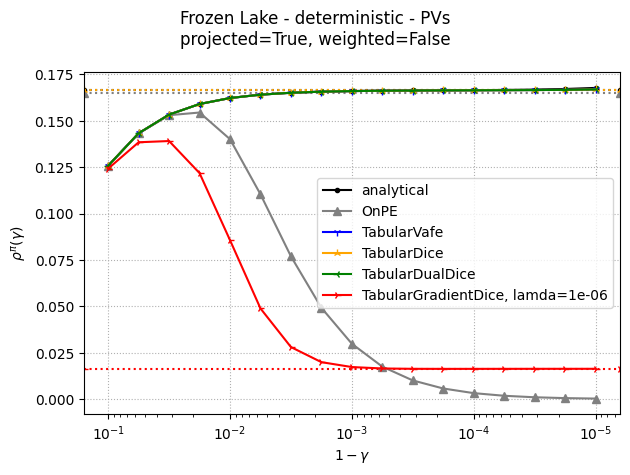

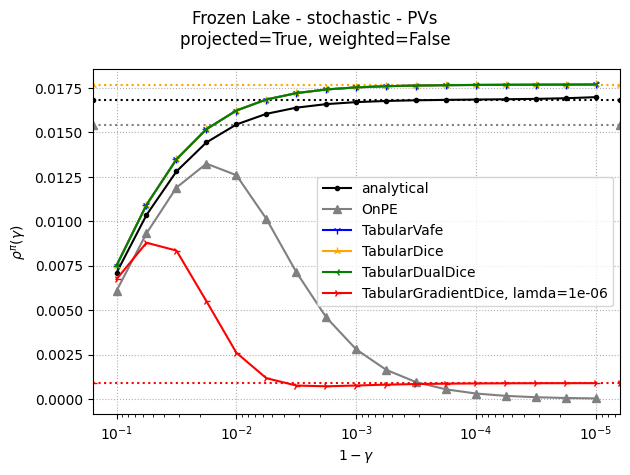

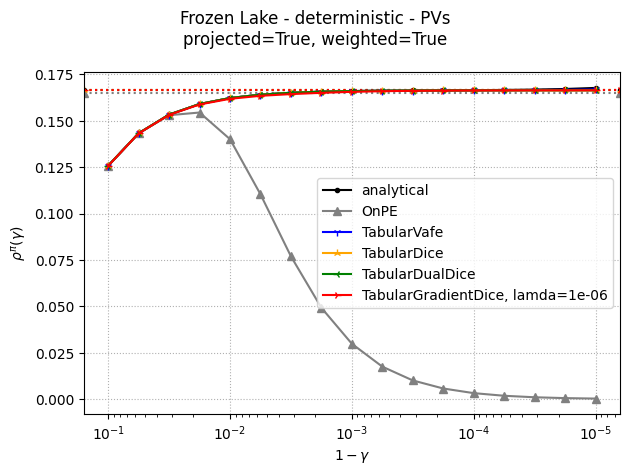

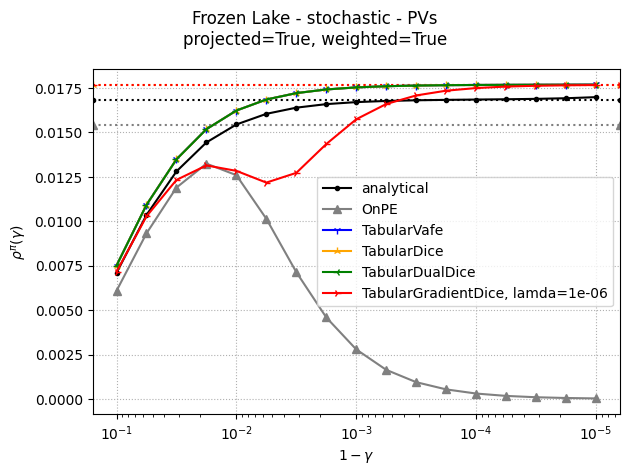

In [110]:
for weighted in [False, True]:
    for kind in kinds:
        plot_pvs_frozen_lake(kind, weighted, errors=False)

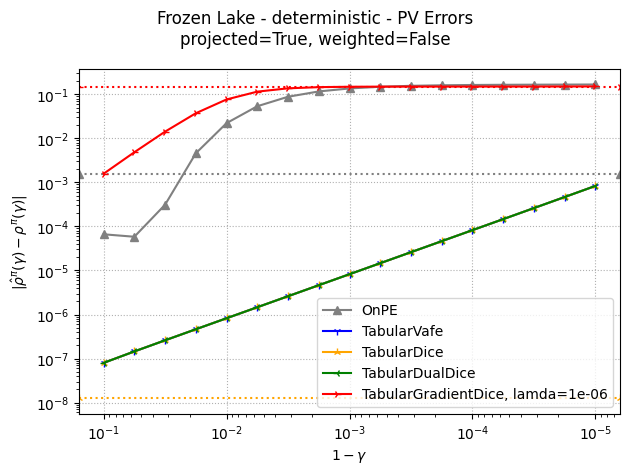

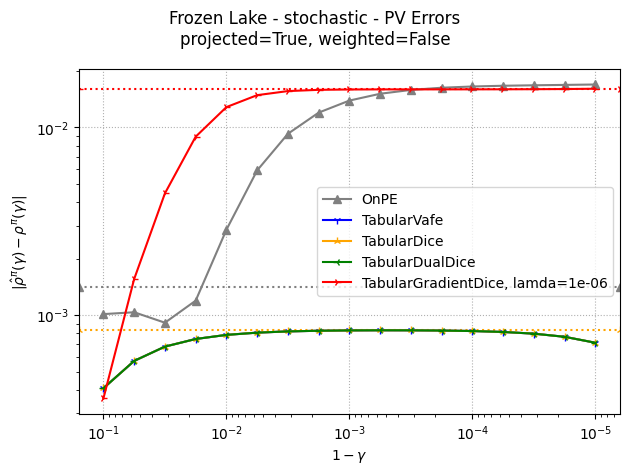

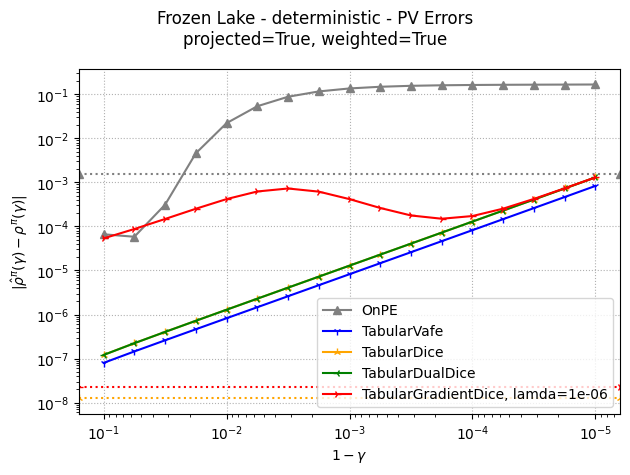

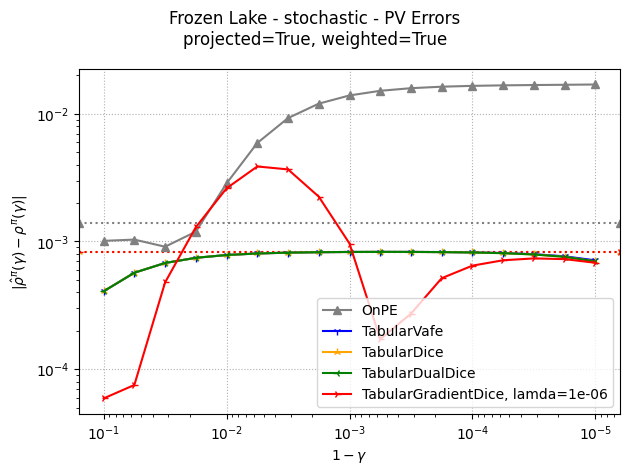

In [111]:
for weighted in [False, True]:
    for kind in kinds:
        plot_pvs_frozen_lake(kind, weighted, errors=True)

## Stationary Distribution Corrections

In [169]:
def plot_sdc_errors_frozen_lake(kind):

    plot_info_analytical_discounted = {
        "x": gammas,
        "y": sdcs[kind]["analytical"],
        "label": "analytical",
        "color": "black",
        "marker": ".",
    }
    plot_info_analytical_undiscounted = {
        "y": sdc[kind]["analytical"],
        "label": None,
        "color": "black",
        "marker": ".",
    }
    plot_infos_discounted = [
        {
            "x": gammas,
            "y": sdcs[kind]["TabularDice"],
            "label": "TabularDice",
            "color": "orange",
            "marker": "2",
        },
        {
            "x": gammas,
            "y": sdcs[kind]["TabularDualDice"],
            "label": "TabularDualDice",
            "color": "green",
            "marker": "3",
        },
        {
            "x": gammas,
            "y": sdcs[kind]["TabularGradientDice"],
            "label": f"TabularGradientDice, lamda={lamda}",
            "color": "red",
            "marker": "4",
        },
    ]
    plot_infos_undiscounted = [
        {
            "y": sdc[kind]["TabularDice"],
            "label": None,
            "color": "orange",
            "marker": "2",
        },
        {
            "y": sdc[kind]["TabularGradientDice"],
            "label": None,
            "color": "red",
            "marker": "4",
        },
    ]
    plot_infos_discounted = [
        {
            "x": plot_info["x"],
            "y": np.mean( ( plot_info["y"] - plot_info_analytical_discounted["y"] ) ** 2, axis=-1, ),
            "label": plot_info["label"],
            "color": plot_info["color"],
            "marker": plot_info["marker"],
        }
            for plot_info in plot_infos_discounted
    ]
    plot_infos_undiscounted = [
        {
            "y": np.mean( ( plot_info["y"] - plot_info_analytical_undiscounted["y"] ) ** 2 ),
            "label": plot_info["label"],
            "color": plot_info["color"],
            "marker": plot_info["marker"],
        }
            for plot_info in plot_infos_undiscounted
    ]
    plot_infos = plot_infos_undiscounted + plot_infos_discounted

    suptitle = f"Frozen Lake - {kind} - SDC MSEs" + "\n" + f"{projected=}"

    one_minus_gamma = True
    scale_pv = False

    xlabel = None
    ylabel = latex_labels["sdc_L2_error"]()

    xlim = None
    ylim = None

    scale_x = True
    scale_y = True

    legend = True
    dir = dir_images

    plot(
        plot_infos,
        suptitle,
        one_minus_gamma, scale_pv,
        xlabel, ylabel,
        xlim, ylim,
        scale_x, scale_y,
        legend,
        dir,
    )

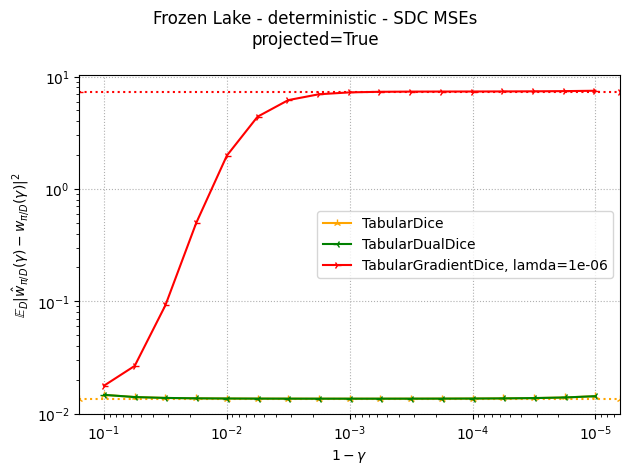

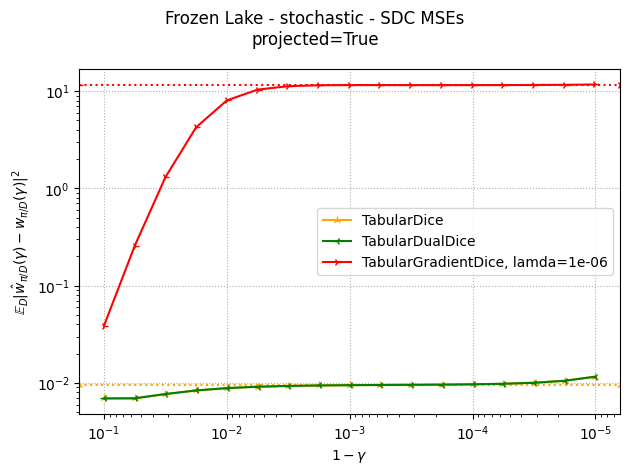

In [170]:
for kind in kinds:
    plot_sdc_errors_frozen_lake(kind)

# Supplementary

## `env` & `env_wrapped`

In [97]:
def execute_test_env(kind, up, num_trajectory, max_trajectory_length=None):
    print(kind); print()
    data = test_env(
        env=env[kind],
        get_act=get_act[kind][up],
        num_trajectory=num_trajectory,
        max_trajectory_length=max_trajectory_length,
        verbosity=2,
    )
    display(data)

In [98]:
execute_test_env(
    kind="deterministic",
    up="uniform",
    num_trajectory=2,
)

deterministic

0, 3 0.0
0, 0 0.0
0, 0 0.0
0, 1 0.0
4, 2 0.0
5, terminated

0, 3 0.0
0, 2 0.0
1, 0 0.0
0, 3 0.0
0, 0 0.0
0, 2 0.0
1, 3 0.0
1, 3 0.0
1, 1 0.0
5, terminated



{'distinct_absolute': (3.0, 0.0),
 'distinct_relative': (0.4, 0.1),
 'all': (8.0, 2.0)}

In [100]:
execute_test_env(
    kind="stochastic",
    up="uniform",
    num_trajectory=2,
)

stochastic

0, 3 0.0
0, 2 0.0
4, 1 0.0
5, terminated

0, 1 0.0
4, 1 0.0
4, 1 0.0
5, terminated



{'distinct_absolute': (3.0, 0.0),
 'distinct_relative': (0.75, 0.0),
 'all': (4.0, 0.0)}

In [ ]:
execute_test_env(
    kind="deterministic",
    up="policy",
    num_trajectory=2,
)

deterministic

0, 1 0.0
4, 1 0.0
8, 2 0.0
9, 2 0.0
10, 1 0.0
14, 2 1.0
15, terminated

0, 1 0.0
4, 1 0.0
8, 2 0.0
9, 1 0.0
13, 2 0.0
14, 2 1.0
15, terminated



{'distinct_absolute': (7.0, 0.0),
 'distinct_relative': (1.0, 0.0),
 'all': (7.0, 0.0)}

In [101]:
execute_test_env(
    kind="stochastic",
    up="policy",
    num_trajectory=2,
)

stochastic

0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
4, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
0, 0 0.0
4, 0 0.0
8, 3 0.0
9, 1 0.0
8, 3 0.0
4, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
4, 0 0.0
8, 3 0.0
8, 3 0.0
4, 0 0.0
8, 3 0.0
4, 0 0.0
0, 0 0.0
4, 0 0.0
4, 0 0.0
4, 0 0.0
4, 0 0.0
4, 0 0.0
4, 0 0.0
8, 3 0.0
8, 3 0.0
9, 1 0.0
13, 2 0.0
9, 1 0.0
10, 0 0.0
9, 1 0.0
8, 3 0.0
9, 1 0.0
13, 2 0.0
14, 1 0.0
13, 2 0.0
13, 2 0.0
13, 2 0.0
9, 1 0.0
10, 0 0.0
9, 1 0.0
10, 0 0.0
6, 1 0.0
7, terminated

0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
0, 0 0.0
4, 0 0.0
8, 3 0.0
9, 1 0.0
10, 0 0.0
14, 1 0.0
14, 1 0.0
14, 1 0.0
13, 2 0.0
13, 2 0.0
14, 1 0.0
13, 2 0.0
14, 3 0.0
10, 0 0.0
9, 1 0.0
10, 0 0.0
6, 2 0.0
7, terminated



{'distinct_absolute': (9.0, 0.0),
 'distinct_relative': (0.2556818181818182, 0.11931818181818182),
 'all': (45.0, 21.0)}

## `transitions_lister`

In [80]:
def list_transitions(se, kind):
    print(kind); print()

    if se == "sample": f = list_transitions_sample
    if se == "exact":  f = list_transitions_exact

    df = f(transitions[se][kind])
    display(df)

In [82]:
for kind in kinds:
    print("#", "-"*64, "#", "\n")
    list_transitions("sample", kind)

# ---------------------------------------------------------------- # 

deterministic



,obs,act,obs_next,rew
0,0,0,"[(0, 1000)]","[(0.0, 1000)]"
1,0,1,"[(4, 1000)]","[(0.0, 1000)]"
2,0,2,"[(1, 1000)]","[(0.0, 1000)]"
3,0,3,"[(0, 1000)]","[(0.0, 1000)]"
4,1,0,"[(0, 1000)]","[(0.0, 1000)]"
...,...,...,...,...
59,14,3,"[(10, 1000)]","[(0.0, 1000)]"
60,15,0,"[(0, 1000)]","[(0, 1000)]"
61,15,1,"[(0, 1000)]","[(0, 1000)]"
62,15,2,"[(0, 1000)]","[(0, 1000)]"


# ---------------------------------------------------------------- # 

stochastic



,obs,act,obs_next,rew
0,0,0,"[(0, 686), (4, 314)]","[(0.0, 1000)]"
1,0,1,"[(0, 346), (1, 289), (4, 365)]","[(0.0, 1000)]"
2,0,2,"[(0, 317), (1, 345), (4, 338)]","[(0.0, 1000)]"
3,0,3,"[(0, 661), (1, 339)]","[(0.0, 1000)]"
4,1,0,"[(0, 666), (1, 334)]","[(0.0, 1000)]"
...,...,...,...,...
59,14,3,"[(0, 354), (10, 323), (13, 323)]","[(0.0, 646), (1.0, 354)]"
60,15,0,"[(0, 1000)]","[(0, 1000)]"
61,15,1,"[(0, 1000)]","[(0, 1000)]"
62,15,2,"[(0, 1000)]","[(0, 1000)]"


In [83]:
for kind in kinds:
    print("#", "-"*64, "#", "\n")
    list_transitions("exact", kind)

# ---------------------------------------------------------------- # 

deterministic



,obs,act,obs_next,probs,rew
0,0,0,0,1,0
1,0,1,4,1,0
2,0,2,1,1,0
3,0,3,0,1,0
4,1,0,0,1,0
...,...,...,...,...,...
59,14,3,10,1,0
60,15,0,0,1,0
61,15,1,0,1,0
62,15,2,0,1,0


# ---------------------------------------------------------------- # 

stochastic



,obs,act,obs_next,probs,rew
0,0,0,"[0, 4]","[2/3, 1/3]",0
1,0,1,"[0, 1, 4]","[1/3, 1/3, 1/3]",0
2,0,2,"[0, 1, 4]","[1/3, 1/3, 1/3]",0
3,0,3,"[0, 1]","[2/3, 1/3]",0
4,1,0,"[0, 1]","[2/3, 1/3]",0
...,...,...,...,...,...
59,14,3,"[0, 10, 13]","[1/3, 1/3, 1/3]",1/3
60,15,0,0,1,0
61,15,1,0,1,0
62,15,2,0,1,0


## `AuxiliaryEstimates`

In [14]:
def test_auxiliary_estimates_frozen_lake(kind):
    test_auxiliary_estimates(
        auxiliary_estimates=auxiliary_estimates[kind],
        title_prefix=f"Frozen Lake - {kind}",
        dir=os.path.join(dir_images, "auxiliary_estimates"),
    )

(s, a) visited:
{'absolute': 64, 'relative': 1.0}
(s, a) not visited:
{'absolute': 0, 'relative': 0.0}

# dD_bar[i] == 0, but P_bar[i, :] != 0: 0
# dD_bar[i] == 0, but P_bar[:, i] != 0: 0
# dD_bar[i], but d0_bar[i] != 0: 0

# ---------------------------------------------------------------- # 



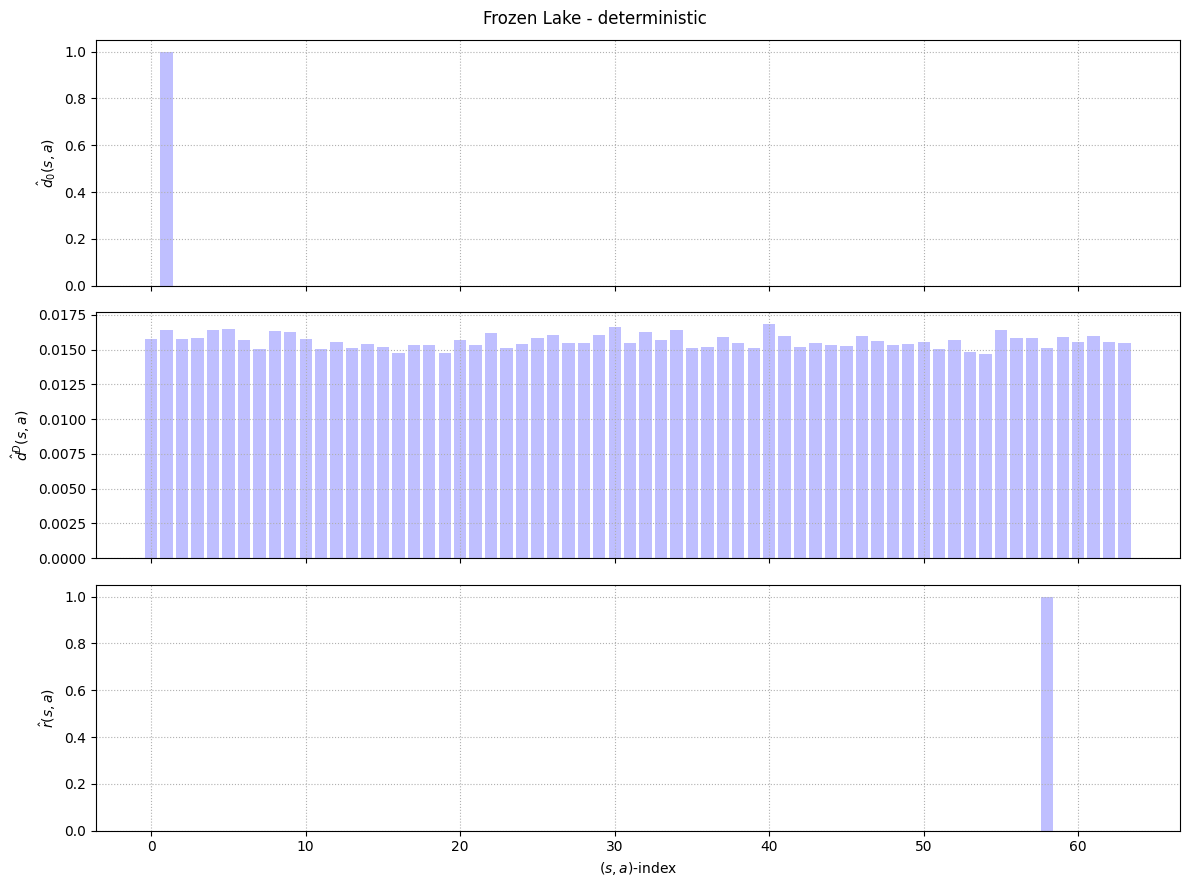

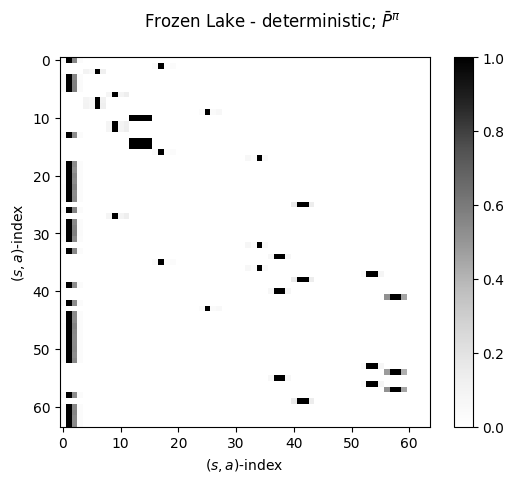

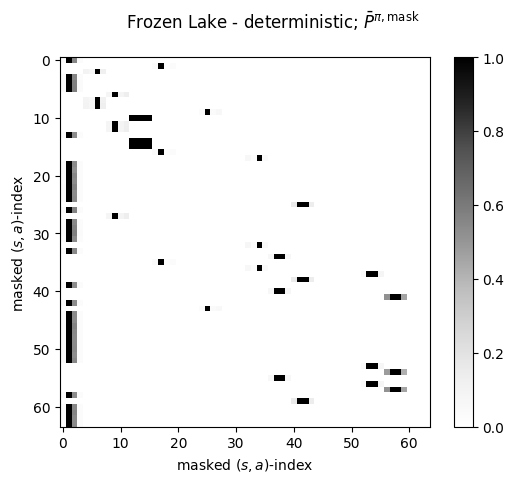

# ---------------------------------------------------------------- # 



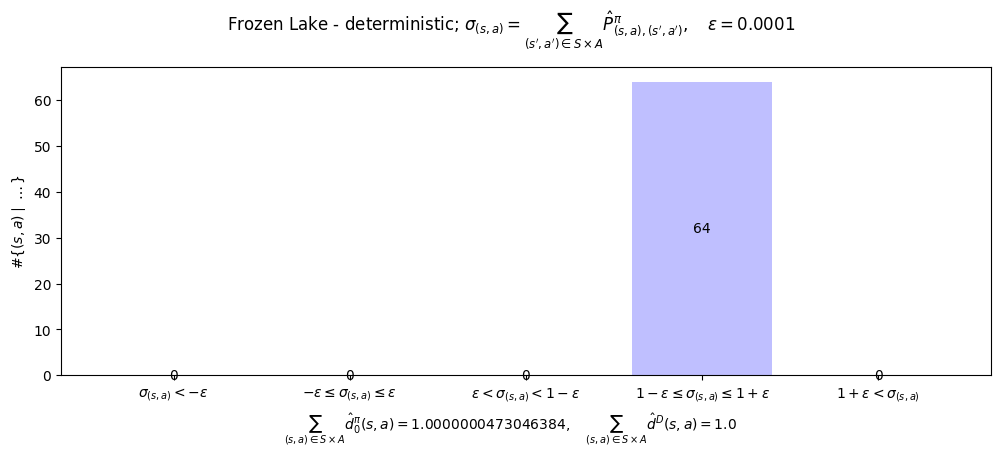

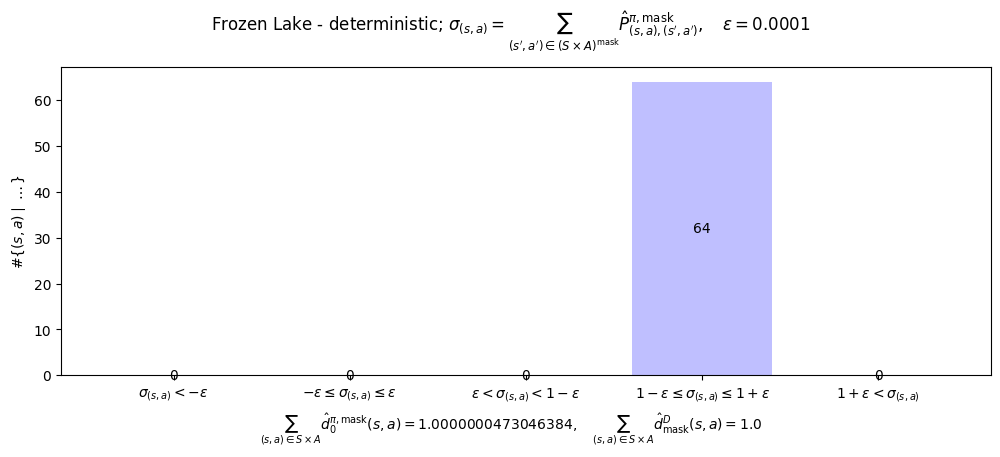

# ---------------------------------------------------------------- # 



In [20]:
test_auxiliary_estimates_frozen_lake("deterministic")

(s, a) visited:
{'absolute': 64, 'relative': 1.0}
(s, a) not visited:
{'absolute': 0, 'relative': 0.0}

# dD_bar[i] == 0, but P_bar[i, :] != 0: 0
# dD_bar[i] == 0, but P_bar[:, i] != 0: 0
# dD_bar[i], but d0_bar[i] != 0: 0

# ---------------------------------------------------------------- # 



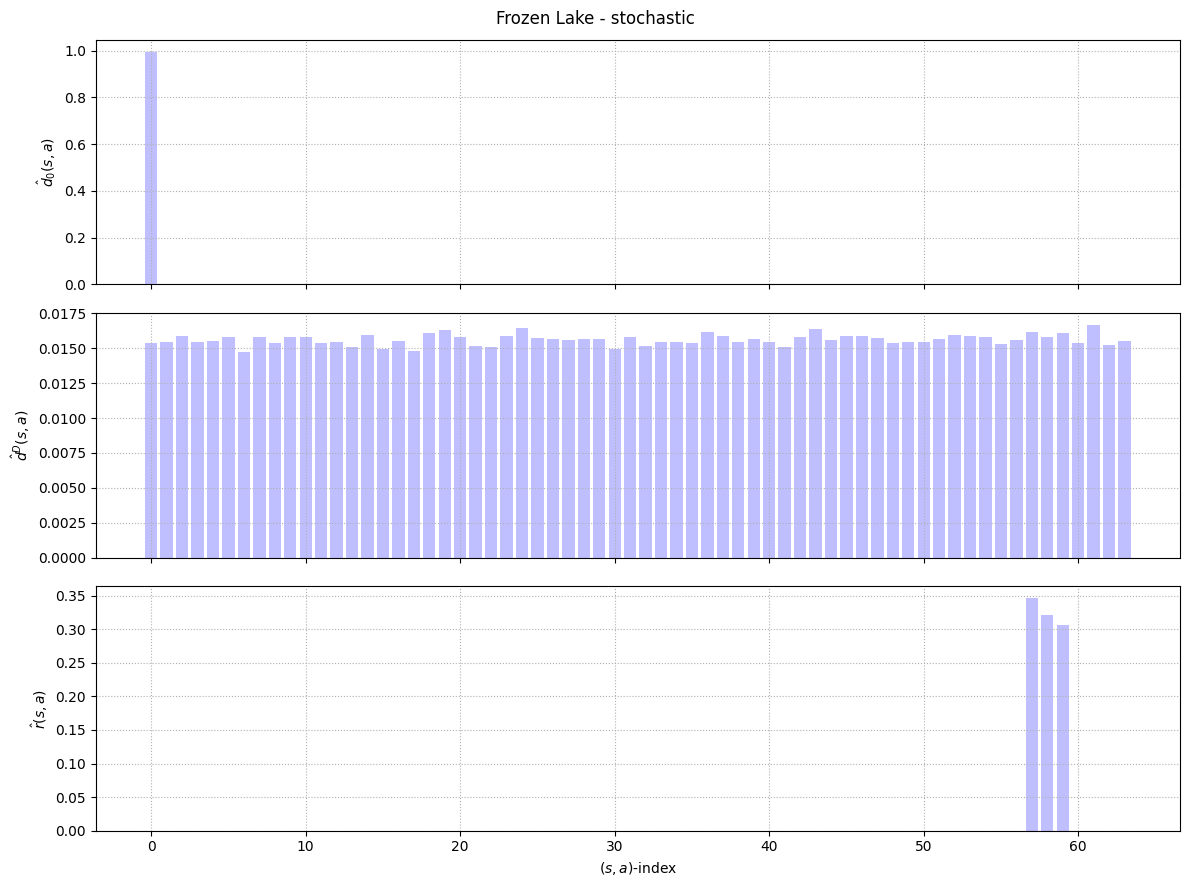

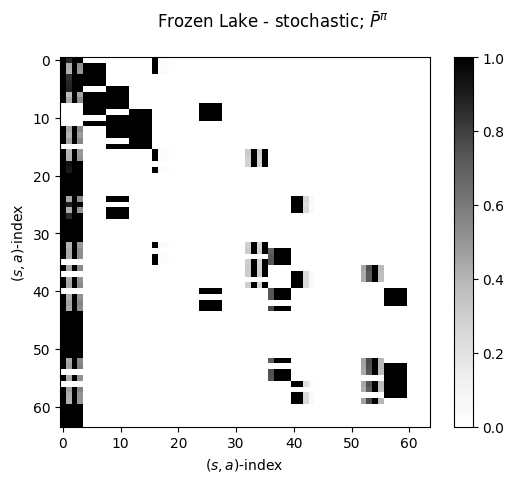

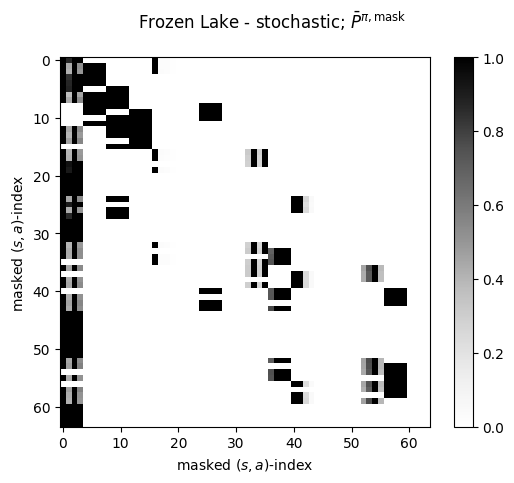

# ---------------------------------------------------------------- # 



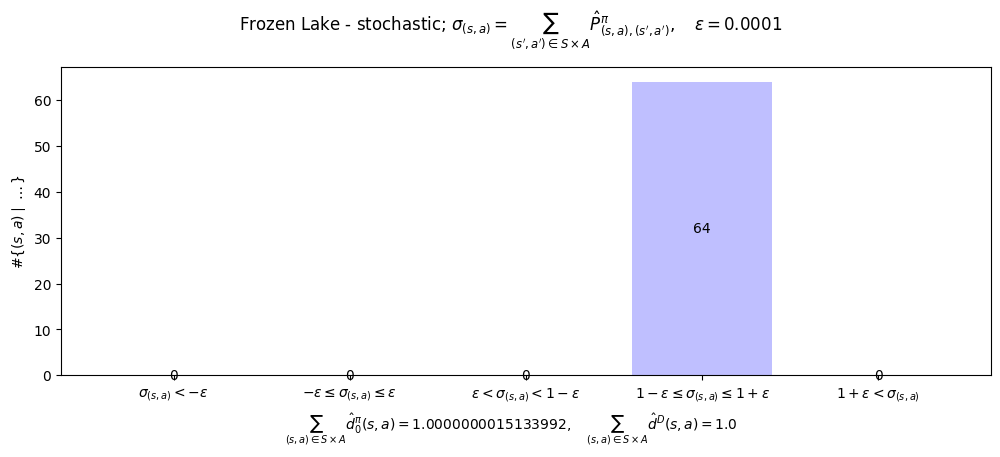

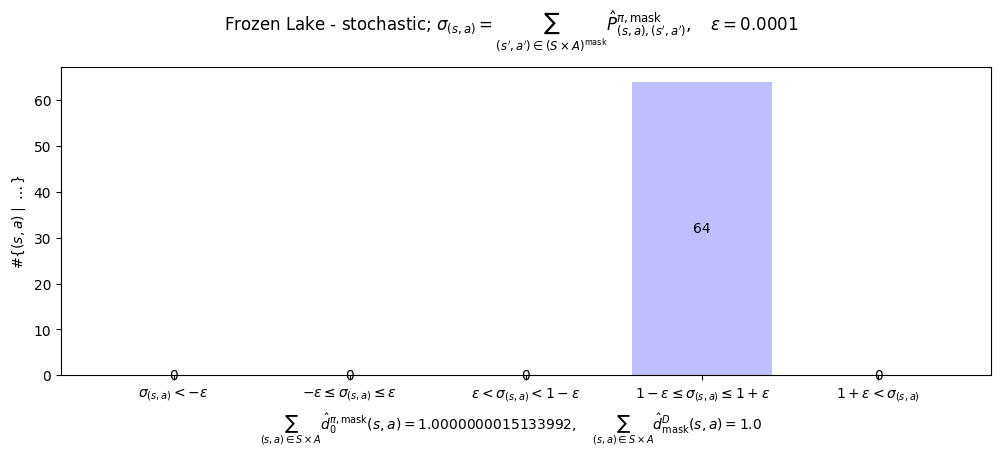

# ---------------------------------------------------------------- # 



In [21]:
test_auxiliary_estimates_frozen_lake("stochastic")